# Homogeneous ReLU Mean-Field Flow

This notebook generates `fig:gradflow-mlp-homogeneous-relu`.  In homogeneous two-layer models, neurons are particles in parameter space and useful teacher features define preferred rays.  The figure shows both particle transport in parameter space and the time evolution of the weighted directional histogram, with denser snapshots near the beginning of training.

In [1]:
from pathlib import Path
import sys
import logging

import matplotlib.pyplot as plt
import numpy as np

ROOT = Path.cwd()
if ROOT.name == "notebooks-figures":
    ROOT = ROOT.parent
sys.path.insert(0, str(ROOT / "notebooks-figures"))

from figure_style import (
    BLUE,
    RED,
    VIOLET,
    ORANGE,
    GRAY,
    LIGHT_GRAY,
    DIRAC_MARKER_SIZE,
    box_axes,
    draw_point_clouds,
    draw_transport_segments,
    figure_dir,
    interp_color,
    padded_limits,
    remove_axes,
    save_pdf,
    setup_matplotlib,
)

setup_matplotlib()
logging.getLogger("fontTools.ttLib.tables._h_e_a_d").setLevel(logging.ERROR)

from matplotlib.collections import LineCollection

NAME = "gradflow-mlp-homogeneous-relu"
out = figure_dir(NAME)
rng = np.random.default_rng(31)

The auxiliary experiment in `aux/mlp/` compares several spectral selectors.  Here we keep only the Wasserstein particle gradient flow: neurons are particles $x_i=(u_i,v_i)$ and the flow follows the first variation of the square-loss mean-field risk.  The display uses the reduced coordinates $(|u|v_1,|u|v_2)$, so concentration on useful homogeneous rays is visible without plotting the full three-dimensional parameter space.


In [2]:
def relu(t):
    return np.maximum(t, 0.0)

def predict(X, z):
    u = X[:, 0]
    v = X[:, 1:3]
    return (u[:, None] * relu(v @ z.T)).mean(axis=0)

def first_variation_gradient(X, z, y):
    u = X[:, 0]
    v = X[:, 1:3]
    logits = v @ z.T
    R = relu(logits)
    residual = (u[:, None] * R).mean(axis=0) - y
    grad_u = R @ residual / len(z)
    active = (logits > 0).astype(float)
    grad_v = (active * residual[None, :]) @ z / len(z)
    grad_v *= u[:, None]
    return np.column_stack([grad_u, grad_v])

def transform_to_pq(X):
    return np.abs(X[:, 0:1]) * X[:, 1:3]

def farthest_point_sample(points, n, seed=0):
    rr = np.random.default_rng(seed)
    points = np.asarray(points, dtype=float)
    start = int(rr.integers(len(points)))
    chosen = [start]
    dist2 = np.sum((points - points[start])**2, axis=1)
    for _ in range(1, min(n, len(points))):
        j = int(np.argmax(dist2))
        chosen.append(j)
        dist2 = np.minimum(dist2, np.sum((points - points[j])**2, axis=1))
    return np.asarray(chosen, dtype=int)

teacher_u = np.array([1.0, 1.0, -1.0])
teacher_angles = np.array([0.38, 2.42, 4.63])
teacher_v = np.column_stack([np.cos(teacher_angles), np.sin(teacher_angles)])
teacher = np.column_stack([teacher_u, teacher_v])
teacher_pq = transform_to_pq(teacher)

z_train = rng.normal(size=(900, 2))
y_train = predict(teacher, z_train)

n = 360
teacher_mean = teacher.mean(axis=0)
teacher_std = teacher.std(axis=0) + np.array([0.12, 0.08, 0.08])
X = teacher_mean + 0.45 * teacher_std * rng.normal(size=(n, 3))
X[:, 0] += 0.06 * rng.normal(size=n)
steps = 760
dt = 0.36
store_every = 10
history = [X.copy()]
for k in range(steps):
    G = first_variation_gradient(X, z_train, y_train)
    gnorm = np.linalg.norm(G, axis=1).max()
    if gnorm > 1e-12:
        G = G / max(gnorm, 1.35)
    X = X - dt * G
    X[:, 0] = np.clip(X[:, 0], -2.2, 2.2)
    radii = np.linalg.norm(X[:, 1:3], axis=1, keepdims=True)
    X[:, 1:3] *= np.minimum(1.8 / np.maximum(radii, 1e-12), 1.0)
    if (k + 1) % store_every == 0 or k + 1 == steps:
        history.append(X.copy())
history = np.stack(history)
times = np.linspace(0, 1, len(history))
final_angles = np.mod(np.arctan2(history[-1,:,2], history[-1,:,1]), 2*np.pi)
all_pq = np.vstack([transform_to_pq(history.reshape(-1, 3)), teacher_pq])
lim = max(np.max(np.abs(all_pq)), 1.0) * 1.04
shown = farthest_point_sample(transform_to_pq(history[0]), 125, seed=37)


In [3]:
def arclength_colors(pts):
    seg_len = np.linalg.norm(np.diff(pts, axis=0), axis=1)
    total = seg_len.sum()
    if total < 1e-12:
        return np.linspace(0, 1, len(seg_len))
    curv = np.concatenate([[0.0], np.cumsum(seg_len)])
    return 0.5 * (curv[:-1] + curv[1:]) / total

fig, ax = plt.subplots(figsize=(2.36, 2.20))
H = np.stack([transform_to_pq(history[k]) for k in range(len(history))])
for i in shown:
    pts = H[:, i, :]
    segments = np.stack([pts[:-1], pts[1:]], axis=1)
    cols = [(*interp_color(float(s)), 0.33) for s in arclength_colors(pts)]
    ax.add_collection(LineCollection(segments, colors=cols, linewidths=0.46, zorder=2))
for p in teacher_pq:
    q = 1.02 * lim * p / (np.linalg.norm(p) + 1e-12)
    ax.plot([0, q[0]], [0, q[1]], color='black', linestyle='--', lw=0.78, alpha=0.82, zorder=1)
ax.scatter(H[0, shown, 0], H[0, shown, 1], s=DIRAC_MARKER_SIZE * 0.28, marker='o', color=RED, edgecolor='none', linewidth=0, alpha=0.56, zorder=3)
ax.scatter(H[-1, shown, 0], H[-1, shown, 1], s=DIRAC_MARKER_SIZE * 0.32, marker='o', color=BLUE, edgecolor='none', linewidth=0, alpha=0.70, zorder=4)
ax.set_xlim(-lim, lim); ax.set_ylim(-lim, lim); ax.set_aspect('equal'); remove_axes(ax)
save_pdf(fig, out / "neuron-trajectories.pdf", pad_inches=0.030)
plt.close(fig)

def circular_density(X, theta_grid, bandwidth=0.15):
    theta = np.mod(np.arctan2(X[:, 2], X[:, 1]), 2*np.pi)
    w = np.abs(X[:, 0]) * np.linalg.norm(X[:, 1:3], axis=1)
    d = theta_grid[:, None] - theta[None, :]
    d = np.arctan2(np.sin(d), np.cos(d))
    K = np.exp(-0.5 * (d / bandwidth)**2)
    dens = K @ w
    area = np.trapezoid(dens, theta_grid)
    return dens / max(area, 1e-12)

theta_grid = np.linspace(0, 2*np.pi, 300)
# Front-load snapshots to reveal the fast initial angular concentration.
snapshot_fractions = np.array([0.00, 0.015, 0.035, 0.075, 0.14, 0.28, 0.55, 1.00])
snap_ids = np.unique(np.round(snapshot_fractions * (len(history)-1)).astype(int))
curves = [circular_density(history[j], theta_grid) for j in snap_ids]
ymax = max(float(np.max(c)) for c in curves)
fig, ax = plt.subplots(figsize=(2.42, 1.62))
for j, curve in zip(snap_ids, curves):
    tau = j / (len(history)-1)
    early = tau < 0.16
    ax.plot(theta_grid, curve, color=interp_color(tau), lw=1.05 if early else 1.18, alpha=0.72 if early else 0.90)
for th in np.mod(teacher_angles, 2*np.pi):
    ax.axvline(th, color='black', linestyle='--', linewidth=0.72, alpha=0.70)
ax.set_xlim(0, 2*np.pi); ax.set_ylim(0, 1.05*ymax)
ax.set_xticks([0, np.pi, 2*np.pi]); ax.set_xticklabels([r"$0$", r"$\pi$", r"$2\pi$"])
ax.set_yticks([])
ax.tick_params(labelsize=7, pad=1.5)
box_axes(ax)
save_pdf(fig, out / "direction-histogram.pdf", pad_inches=0.035)
plt.close(fig)


## Figure preview

The output below embeds the current generated thumbnail so the figure renders directly on GitHub.


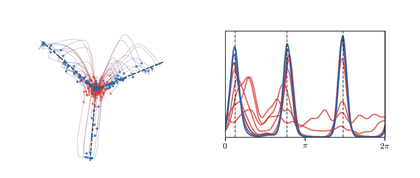

In [4]:
from pathlib import Path
from IPython.display import Image, display
_thumb = Path("thumbnails/gradflow-mlp-homogeneous-relu.png")
if not _thumb.exists():
    _thumb = Path("notebooks-figures/thumbnails/gradflow-mlp-homogeneous-relu.png")
display(Image(filename=str(_thumb)))
